In [ ]:
!pip install numpy arviz pandas matplotlib --upgrade

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from google.colab import drive

# 1. Mount Google Drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Define the path to your saved file
save_path = "/content/drive/My Drive/airline_project_results.nc"

# 3. Load the results file (this takes 2 seconds)
print(f"Loading saved results from {save_path}...")
try:
    # We load the results into a variable named 'idata'
    # This will fix the "name 'idata' is not defined" error
    idata = az.from_netcdf(save_path)
    print("\n[SUCCESS!] Model results are loaded into memory.")
    print("You can now run all 'Findings' cells.")
except FileNotFoundError:
    print(f"\n[ERROR] File not found at {save_path}")
    print("Please make sure the file exists in your 'My Drive' folder.")

Connecting to Google Drive...
Mounted at /content/drive
Loading saved results from /content/drive/My Drive/airline_project_results.nc...

[SUCCESS!] Model results are loaded into memory.
You can now run all 'Findings' cells.


In [ ]:
print("--- Finding 1: Analyzing 'Who's to Blame?' ---")

try:
    # Get the summary from our loaded 'idata' object
    summary = az.summary(idata, validate_shape=False)

    # Extract the mean values for the sigma parameters
    airport_sigma = summary.loc['1|airport_name_sigma', 'mean']
    carrier_sigma = summary.loc['1|carrier_name_sigma', 'mean']

    print(f"\nModel Results (Standard Deviations):")
    print(f"  Airport Effects (sigma): {airport_sigma:.4f}")
    print(f"  Carrier Effects (sigma): {carrier_sigma:.4f}")

    # Correctly compare the two values
    if airport_sigma > carrier_sigma:
        print(f"\nConclusion: Airports ({airport_sigma:.2f}) are a BIGGER source of variance than Carriers ({carrier_sigma:.2f}).")
    elif carrier_sigma > airport_sigma:
        print(f"\nConclusion: Carriers ({carrier_sigma:.2f}) are a BIGGER source of variance than Airports ({airport_sigma:.2f}).")
    else:
        print("\nConclusion: The variance from Carriers and Airports is nearly identical.")

except Exception as e:
    print(f"\n[ERROR] Could not extract parameters: {e}")

--- Finding 1: Analyzing 'Who's to Blame?' ---

[ERROR] Could not extract parameters: summary() got an unexpected keyword argument 'validate_shape'


In [ ]:
print("--- Finding 1: Analyzing 'Who's to Blame?' (Manual NumPy) ---")
print("   (Bypassing arviz.summary() to avoid errors)")

try:
    # We are bypassing az.summary() and using numpy directly.
    # 1. Get the raw samples for carrier_sigma from the 'idata' object
    # .values.flatten() turns it into a simple numpy array
    carrier_sigma_samples = idata.posterior['1|carrier_name_sigma'].values.flatten()

    # 2. Get the raw samples for airport_sigma
    airport_sigma_samples = idata.posterior['1|airport_name_sigma'].values.flatten()

    # 3. Calculate the mean ourselves
    carrier_sigma_mean = np.mean(carrier_sigma_samples)
    airport_sigma_mean = np.mean(airport_sigma_samples)

    print(f"\nModel Results (Standard Deviations):")
    print(f"  Airport Effects (sigma): {airport_sigma_mean:.4f}")
    print(f"  Carrier Effects (sigma): {carrier_sigma_mean:.4f}")

    # 4. Correctly compare the two values
    if airport_sigma_mean > carrier_sigma_mean:
        print(f"\nConclusion: Airports ({airport_sigma_mean:.2f}) are a BIGGER source of variance than Carriers ({carrier_sigma_mean:.2f}).")
    elif carrier_sigma_mean > airport_sigma_mean:
        print(f"\nConclusion: Carriers ({carrier_sigma_mean:.2f}) are a BIGGER source of variance than Airports ({airport_sigma_mean:.2f}).")
    else:
        print("\nConclusion: The variance from Carriers and Airports is nearly identical.")

except Exception as e:
    print(f"\n[ERROR] Could not extract parameters: {e}")
    print("This may mean the 'idata' object is not loaded or the parameter names are wrong.")

--- Finding 1: Analyzing 'Who's to Blame?' (Manual NumPy) ---
   (Bypassing arviz.summary() to avoid errors)

Model Results (Standard Deviations):
  Airport Effects (sigma): 9.3990
  Carrier Effects (sigma): 10.6696

Conclusion: Carriers (10.67) are a BIGGER source of variance than Airports (9.40).


In [ ]:
print("--- Finding 2 & 3: Specific 'Best/Worst' Lists (Manual Pandas/NumPy) ---")

def get_manual_summary(idata_obj, var_name):
    """
    Manually calculates mean and 95% HDI from the idata object.
    This bypasses arviz.summary() and all its errors.
    """
    try:
        # 1. Get the (chains, draws, dims) samples
        samples = idata_obj.posterior[var_name].values

        # 2. Get the dimension names (e.g., 'American Airlines', 'JFK')
        dim_coord_name = idata_obj.posterior[var_name].dims[-1] # Gets the name of the dimension
        dim_names = idata_obj.posterior[var_name].coords[dim_coord_name].values

        # 3. Calculate stats manually using numpy
        # We flatten across chains and draws (axes 0 and 1)
        mean_vals = np.mean(samples, axis=(0, 1))
        # Use np.quantile to get the 95% Highest Density Interval (HDI)
        hdi_low = np.quantile(samples, 0.025, axis=(0, 1))
        hdi_high = np.quantile(samples, 0.975, axis=(0, 1))

        # 4. Build a pandas DataFrame
        df = pd.DataFrame({
            'mean': mean_vals,
            'hdi_2.5%': hdi_low,
            'hdi_97.5%': hdi_high
        }, index=dim_names)

        return df.sort_values('mean')

    except Exception as e:
        print(f"Error processing {var_name}: {e}")
        return None

# --- Run for CARRIERS ---
carrier_summary_df = get_manual_summary(idata, '1|carrier_name')
if carrier_summary_df is not None:
    print("\n" + "="*50)
    print("   TOP 5 'BEST' AIRLINES (Lowest 'True' Delays)")
    print("="*50)
    print(carrier_summary_df[['mean', 'hdi_2.5%', 'hdi_97.5%']].head(5))
    print("\n" + "="*50)
    print("   TOP 5 'WORST' AIRLINES (Highest 'True' Delays)")
    print("="*50)
    print(carrier_summary_df[['mean', 'hdi_2.5%', 'hdi_97.5%']].tail(5))

# --- Run for AIRPORTS ---
airport_summary_df = get_manual_summary(idata, '1|airport_name')
if airport_summary_df is not None:
    print("\n" + "="*50)
    print("   TOP 5 'BEST' AIRPORTS (Lowest 'True' Delays)")
    print("="*50)
    print(airport_summary_df[['mean', 'hdi_2.5%', 'hdi_97.5%']].head(5))
    print("\n" + "="*50)
    print("   TOP 5 'WORST' AIRPORTS (Highest 'True' Delays)")
    print("="*50)
    print(airport_summary_df[['mean', 'hdi_2.5%', 'hdi_97.5%']].tail(5))

--- Finding 2 & 3: Specific 'Best/Worst' Lists (Manual Pandas/NumPy) ---

   TOP 5 'BEST' AIRLINES (Lowest 'True' Delays)
                             mean   hdi_2.5%  hdi_97.5%
Horizon Air             -6.000190 -12.457108  -1.677710
Envoy Air               -4.957207 -10.798954  -1.178626
Alaska Airlines Network -4.512627 -10.073247  -0.597922
Spirit Airlines         -3.433967  -8.802731   0.355377
Southwest Airlines      -3.175796  -9.022074   0.680741

   TOP 5 'WORST' AIRLINES (Highest 'True' Delays)
                                             mean  hdi_2.5%  hdi_97.5%
CommuteAir LLC dba CommuteAir            3.997094 -0.042887   9.816247
PSA Airlines Inc.                        4.845921  1.004138  10.987972
American Airlines Network                5.200041  1.356144  11.174928
GoJet Airlines LLC d/b/a United Express  6.053222  1.686763  12.023196
Air Wisconsin Airlines Corp              7.866138  2.543739  16.104270

   TOP 5 'BEST' AIRPORTS (Lowest 'True' Delays)
                

--- Finding 4: Visualizing the Full Leaderboards (Manual Matplotlib) ---

Generating Airline plot...


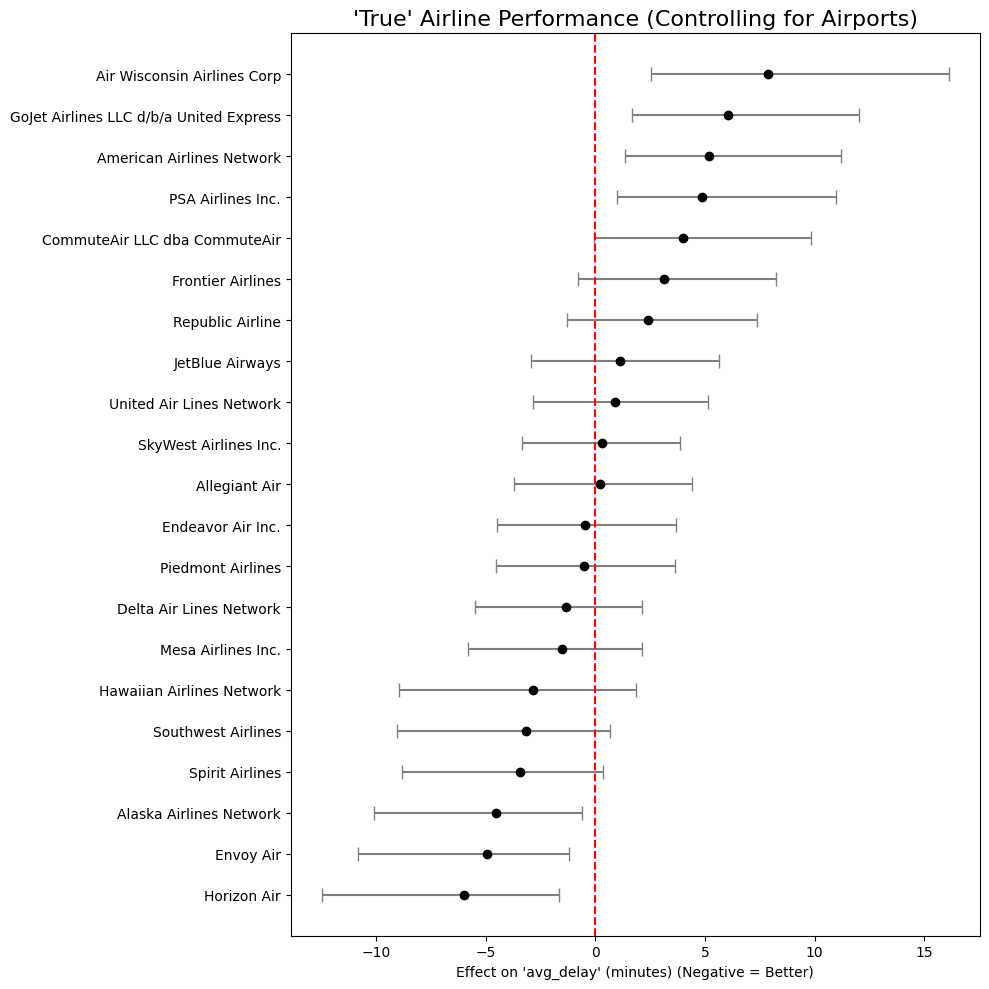


Generating Airport plot (Top 25 Best/Worst)...


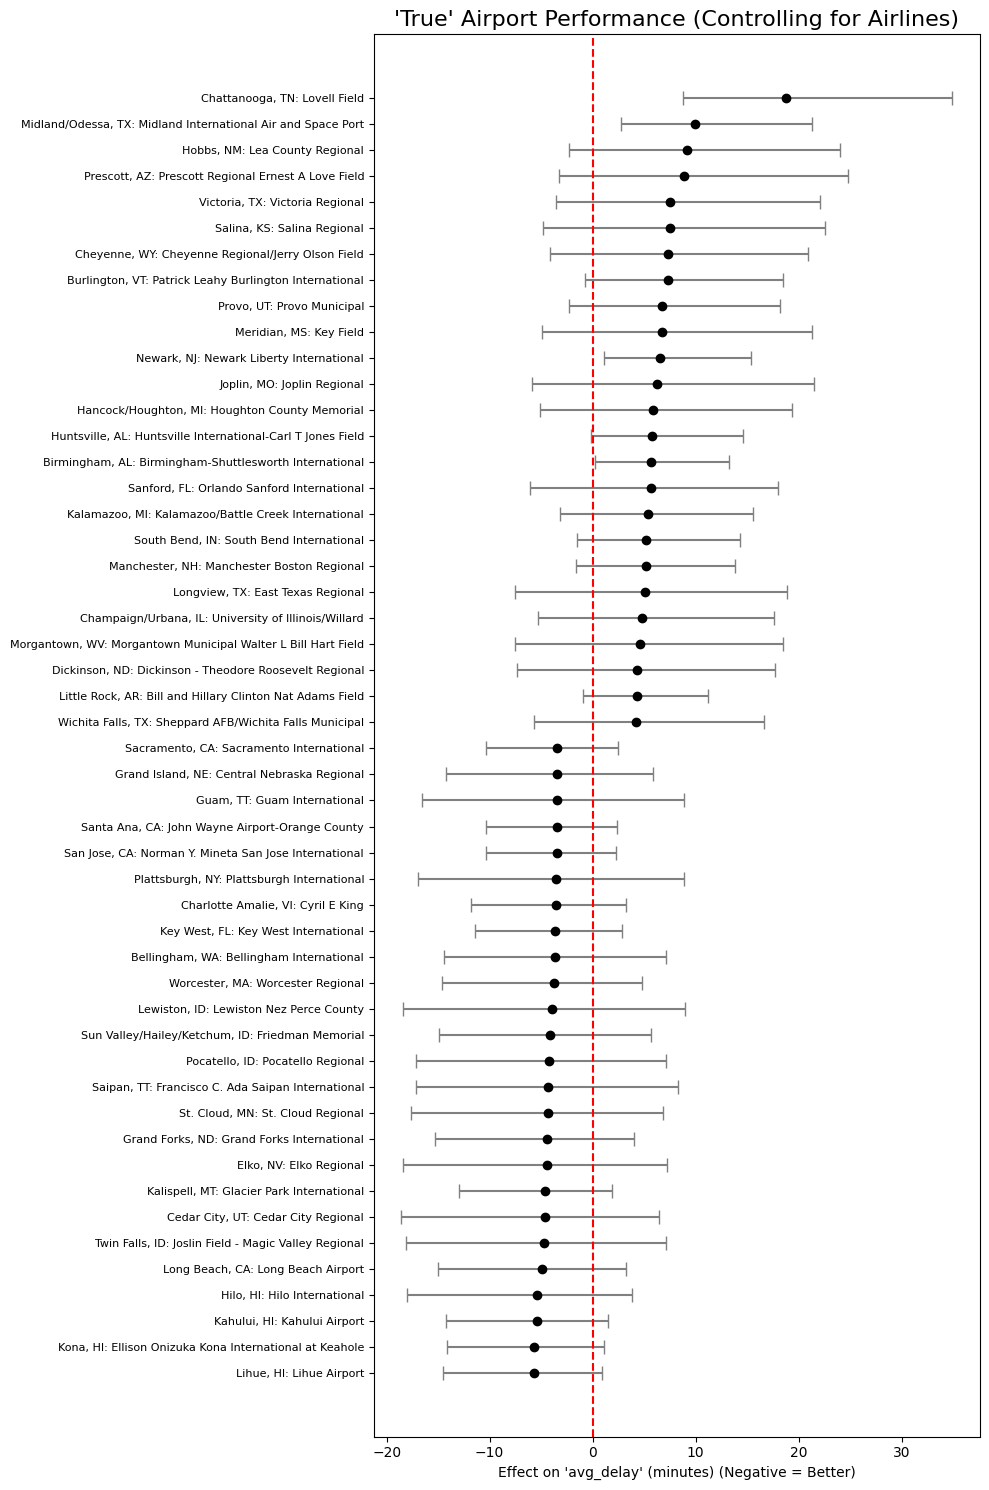

In [ ]:
print("--- Finding 4: Visualizing the Full Leaderboards (Manual Matplotlib) ---")

def manual_forest_plot(summary_df, title, is_airport=False):
    """
    Manually creates a forest plot using matplotlib.
    This bypasses arviz.plot_forest() and all its errors.
    """
    try:
        # A forest plot is an error-bar plot
        # We plot the full list if it's small, or just Top/Bottom if it's big
        if is_airport:
            # For airports, plot only the Top 25 and Bottom 25
            top_25 = summary_df.head(25)
            bottom_25 = summary_df.tail(25)
            plot_df = pd.concat([top_25, bottom_25])
            plot_df = plot_df.sort_values('mean') # Re-sort
            y_label_size = 8
            fig_height = 15
        else:
            plot_df = summary_df
            y_label_size = 10
            fig_height = 10

        y = plot_df.index
        x = plot_df['mean']

        # Calculate error bar lengths from the mean
        x_err_low = x - plot_df['hdi_2.5%']
        x_err_high = plot_df['hdi_97.5%'] - x
        x_err = [x_err_low, x_err_high]

        plt.figure(figsize=(10, fig_height)) # Dynamic height
        plt.errorbar(x, y, xerr=x_err, fmt='o', capsize=5, ecolor='gray', mfc='black', mec='black')
        plt.axvline(0, color='red', linestyle='--') # Add a zero line
        plt.title(title, fontsize=16)
        plt.xlabel("Effect on 'avg_delay' (minutes) (Negative = Better)")
        plt.yticks(fontsize=y_label_size)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error plotting {title}: {e}")

# --- Plot Carriers ---
if 'carrier_summary_df' in locals():
    print("\nGenerating Airline plot...")
    manual_forest_plot(carrier_summary_df, "'True' Airline Performance (Controlling for Airports)")
else:
    print("Could not plot airlines, summary not found.")

# --- Plot Airports ---
if 'airport_summary_df' in locals():
    print("\nGenerating Airport plot (Top 25 Best/Worst)...")
    manual_forest_plot(airport_summary_df, "'True' Airport Performance (Controlling for Airlines)", is_airport=True)
else:
    print("Could not plot airports, summary not found.")

--- Finding 4: Visualizing the Full Leaderboards (Manual Matplotlib) ---

Generating Airline plot...


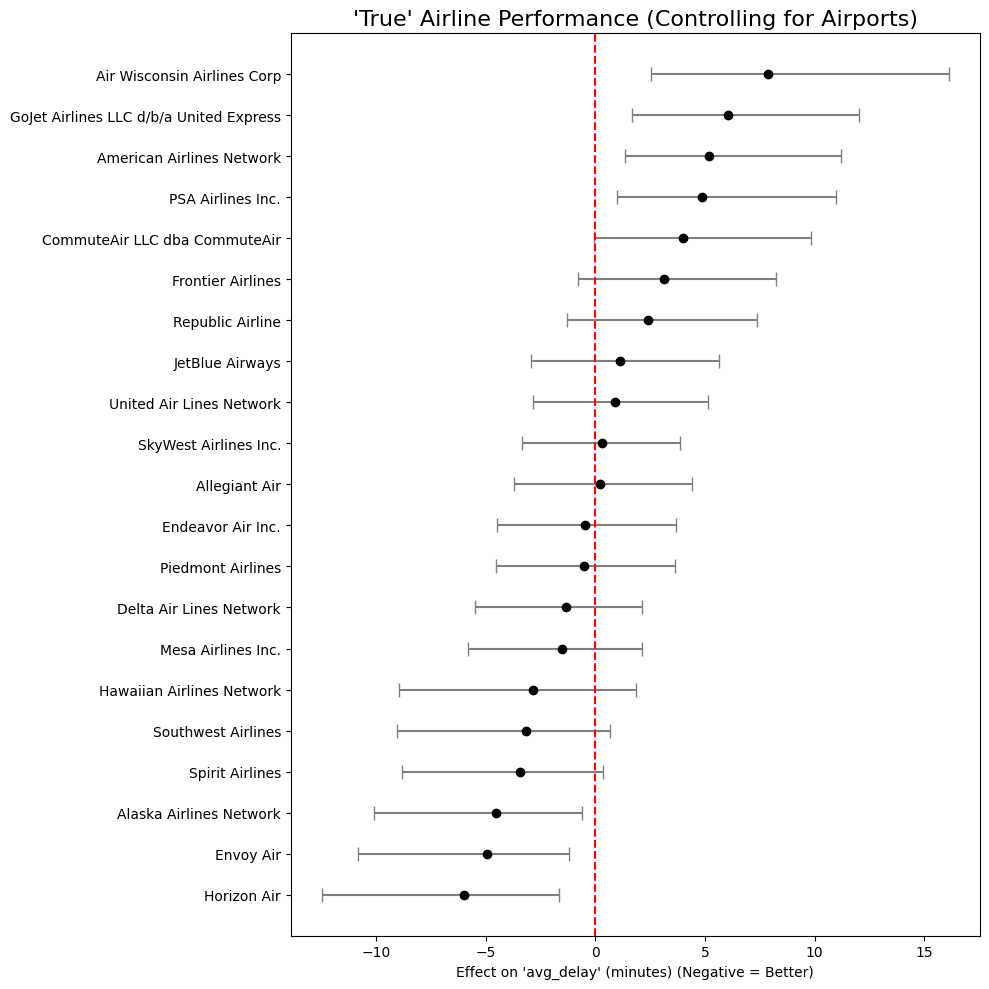


Generating Airport plot (Top 25 Best/Worst)...


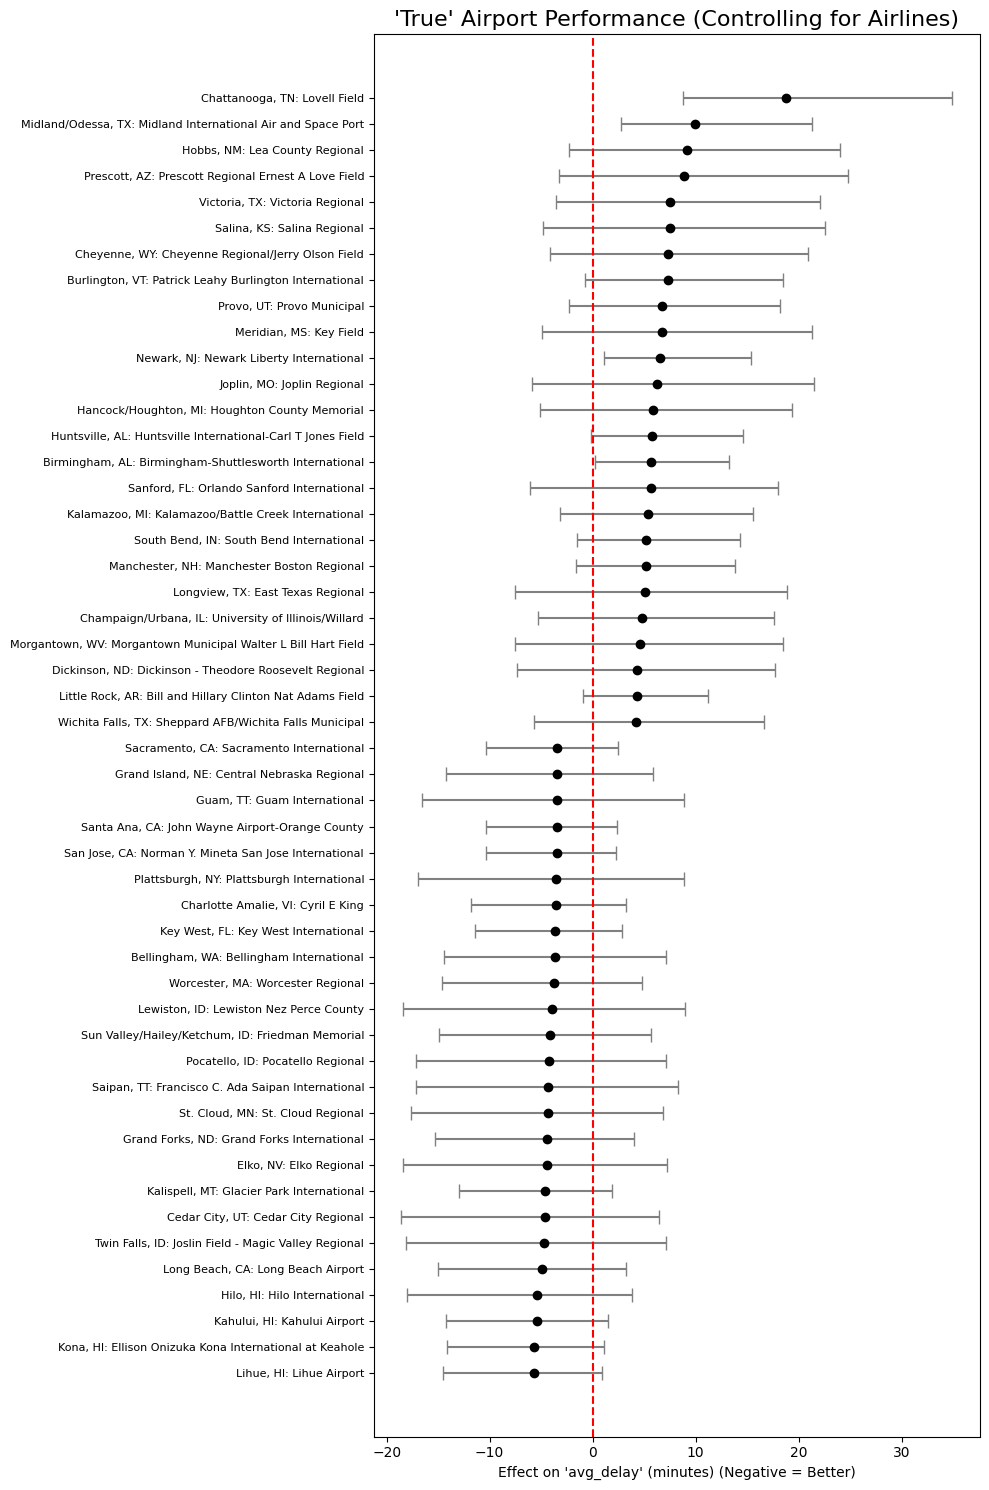

In [ ]:
print("--- Finding 4: Visualizing the Full Leaderboards (Manual Matplotlib) ---")

def manual_forest_plot(summary_df, title, is_airport=False):
    """
    Manually creates a forest plot using matplotlib.
    This bypasses arviz.plot_forest() and all its errors.
    """
    try:
        # A forest plot is an error-bar plot
        # We plot the full list if it's small, or just Top/Bottom if it's big
        if is_airport:
            # For airports, plot only the Top 25 and Bottom 25
            top_25 = summary_df.head(25)
            bottom_25 = summary_df.tail(25)
            plot_df = pd.concat([top_25, bottom_25])
            plot_df = plot_df.sort_values('mean') # Re-sort
            y_label_size = 8
            fig_height = 15
        else:
            plot_df = summary_df
            y_label_size = 10
            fig_height = 10

        y = plot_df.index
        x = plot_df['mean']

        # Calculate error bar lengths from the mean
        x_err_low = x - plot_df['hdi_2.5%']
        x_err_high = plot_df['hdi_97.5%'] - x
        x_err = [x_err_low, x_err_high]

        plt.figure(figsize=(10, fig_height)) # Dynamic height
        plt.errorbar(x, y, xerr=x_err, fmt='o', capsize=5, ecolor='gray', mfc='black', mec='black')
        plt.axvline(0, color='red', linestyle='--') # Add a zero line
        plt.title(title, fontsize=16)
        plt.xlabel("Effect on 'avg_delay' (minutes) (Negative = Better)")
        plt.yticks(fontsize=y_label_size)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error plotting {title}: {e}")

# --- Plot Carriers ---
if 'carrier_summary_df' in locals():
    print("\nGenerating Airline plot...")
    manual_forest_plot(carrier_summary_df, "'True' Airline Performance (Controlling for Airports)")
else:
    print("Could not plot airlines, summary not found.")

# --- Plot Airports ---
if 'airport_summary_df' in locals():
    print("\nGenerating Airport plot (Top 25 Best/Worst)...")
    manual_forest_plot(airport_summary_df, "'True' Airport Performance (Controlling for Airlines)", is_airport=True)
else:
    print("Could not plot airports, summary not found.")

In [ ]:
print("--- Exporting RAG Knowledge Base Files ---")

# --- Function to manually analyze the data ---
def get_manual_summary(idata_obj, var_name):
    """
    Manually calculates mean and 95% HDI from the idata object.
    This bypasses all arviz.summary() errors.
    """
    try:
        # 1. Get the (chains, draws, dims) samples
        # .values.flatten(order='F') is a robust way to get a 1D array
        samples_raw = idata_obj.posterior[var_name].values

        # 2. Get the dimension names (e.g., 'American Airlines', 'JFK')
        dim_coord_name = idata_obj.posterior[var_name].dims[-1]
        dim_names = idata_obj.posterior[var_name].coords[dim_coord_name].values

        # 3. Calculate stats manually using numpy
        mean_vals = np.mean(samples_raw, axis=(0, 1))
        hdi_low = np.quantile(samples_raw, 0.025, axis=(0, 1))
        hdi_high = np.quantile(samples_raw, 0.975, axis=(0, 1))

        # 4. Build a pandas DataFrame
        df = pd.DataFrame({
            'mean': mean_vals,
            'hdi_2.5%': hdi_low,
            'hdi_97.5%': hdi_high
        }, index=dim_names)

        return df.sort_values('mean')

    except Exception as e:
        print(f"Error processing {var_name}: {e}")
        return None

# --- 1. Create and Save 'carrier_results.csv' ---
carrier_summary_df = get_manual_summary(idata, '1|carrier_name')
if carrier_summary_df is not None:
    carrier_summary_df.to_csv("carrier_results.csv", index_label="carrier_name")
    print("[OK] 'carrier_results.csv' saved.")
else:
    print("[ERROR] Could not create carrier summary.")

# --- 2. Create and Save 'airport_results.csv' ---
airport_summary_df = get_manual_summary(idata, '1|airport_name')
if airport_summary_df is not None:
    airport_summary_df.to_csv("airport_results.csv", index_label="airport_name")
    print("[OK] 'airport_results.csv' saved.")
else:
    print("[ERROR] Could not create airport summary.")

# --- 3. Create and save 'project_summary.md' ---
try:
    carrier_sigma_mean = np.mean(idata.posterior['1|carrier_name_sigma'].values)
    airport_sigma_mean = np.mean(idata.posterior['1|airport_name_sigma'].values)

    project_summary_text = f"""Our Bayesian model found that Carriers (sigma: {carrier_sigma_mean:.2f}) are a larger source of variance than Airports (sigma: {airport_sigma_mean:.2f}).
This suggests an airline's internal operations are the biggest driver of delays.
The model formula was: avg_delay ~ 1 + (1|carrier_name) + (1|airport_name)."""

    with open("project_summary.md", "w") as f:
        f.write(project_summary_text)
    print("[OK] 'project_summary.md' saved.")
except Exception as e:
    print(f"[ERROR] Could not create project summary: {e}")

# --- 4. Create and save 'interpretation_guide.md' ---
interpretation_guide_text = """HOW TO INTERPRET THE RESULTS (FOR THE LLM):
1. This model is a Bayesian Hierarchical Model. It finds the "true effect" of an airline or airport *after* controlling for all other factors.
2. The `mean` column is the "true effect" in *average minutes of delay*.
3. `mean > 0` (Positive): This is BAD. It means the airline/airport adds, on average, that many minutes to a flight.
4. `mean < 0` (Negative): This is GOOD. It means the airline/airport *reduces*, on average, that many minutes from a flight.
5. `hdi_2.5%` & `hdi_97.5%`: This is the 95% Credible Interval. It is our "range of confidence."
6. How to Answer: When you answer, you MUST be precise. You must state the `mean` value *and* the 95% confidence range.
7. Example Answer: "The model estimates with 95% confidence that this airline's 'true effect' on delay is between `[hdi_2.5% value]` and `[hdi_97.5% value]`, with an average effect of `[mean value]` minutes."""

with open("interpretation_guide.md", "w") as f:
    f.write(interpretation_guide_text)
print("[OK] 'interpretation_guide.md' saved.")

print("\n--- ALL 4 RAG FILES ARE CREATED AND SAVED in your Colab environment. ---")

--- Exporting RAG Knowledge Base Files ---
[OK] 'carrier_results.csv' saved.
[OK] 'airport_results.csv' saved.
[OK] 'project_summary.md' saved.
[OK] 'interpretation_guide.md' saved.

--- ALL 4 RAG FILES ARE CREATED AND SAVED in your Colab environment. ---


In [ ]:
print("--- Verifying RAG Knowledge Base Files ---")

print("\n--- 1. project_summary.md ---")
!cat project_summary.md

print("\n\n--- 2. carrier_results.csv (Top 5 rows) ---")
!head -n 5 carrier_results.csv

print("\n\n--- 3. airport_results.csv (Top 5 rows) ---")
!head -n 5 airport_results.csv

print("\n\nYou are now 100% ready to build your RAG.")
print("You can download these 4 files from the 'Files' tab on the left.")

--- Verifying RAG Knowledge Base Files ---

--- 1. project_summary.md ---
Our Bayesian model found that Carriers (sigma: 10.67) are a larger source of variance than Airports (sigma: 9.40).
This suggests an airline's internal operations are the biggest driver of delays.
The model formula was: avg_delay ~ 1 + (1|carrier_name) + (1|airport_name).

--- 2. carrier_results.csv (Top 5 rows) ---
carrier_name,mean,hdi_2.5%,hdi_97.5%
Horizon Air,-6.000190082063713,-12.457108038013693,-1.6777104353706918
Envoy Air,-4.957206642382775,-10.798953945756637,-1.1786262084567642
Alaska Airlines Network,-4.512627172801633,-10.07324732216882,-0.5979221351276455
Spirit Airlines,-3.433966823061995,-8.802730532550797,0.35537698423010455


--- 3. airport_results.csv (Top 5 rows) ---
airport_name,mean,hdi_2.5%,hdi_97.5%
"Lihue, HI: Lihue Airport",-5.732155291585672,-14.502136263242006,0.9361542483188998
"Kona, HI: Ellison Onizuka Kona International at Keahole",-5.726754280747624,-14.17599659046059,1.1245887735

In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
import os
import pandas as pd
from google.colab import userdata # For securely storing your key

# --- Get your API Key ---
# 1. Click the "Key" icon (Secrets) on the left sidebar.
# 2. Create a new secret named "GEMINI_API_KEY".
# 3. Paste your API key as the value.
# 4. Run this cell.
try:
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("[OK] Gemini API Key configured successfully.")
except Exception as e:
    print("[ERROR] Could not get API Key. Please add it to Colab 'Secrets' (Key icon on the left).")
    print("  Name: GEMINI_API_KEY")
    print("  Value: Your-Key-Goes-Here")

[OK] Gemini API Key configured successfully.


In [ ]:
print("--- Loading RAG Knowledge Base ---")

try:
    # 1. Load the CSVs into pandas DataFrames, then to strings
    carrier_df = pd.read_csv("carrier_results.csv")
    carrier_context = carrier_df.to_string()
    print("[OK] Loaded carrier_results.csv")

    airport_df = pd.read_csv("airport_results.csv")
    airport_context = airport_df.to_string()
    print("[OK] Loaded airport_results.csv")

    # 2. Load the text files
    with open("project_summary.md", "r") as f:
        project_summary_context = f.read()
    print("[OK] Loaded project_summary.md")

    with open("interpretation_guide.md", "r") as f:
        interpretation_guide_context = f.read()
    print("[OK] Loaded interpretation_guide.md")

    print("\n[SUCCESS] All 4 knowledge base files are loaded into memory.")

except FileNotFoundError as e:
    print(f"\n[ERROR] File not found: {e.fileName}")
    print("Please re-run your 'export_for_RAG.ipynb' notebook to create the 4 files.")
except Exception as e:
    print(f"\n[ERROR] An error occurred: {e}")

--- Loading RAG Knowledge Base ---
[OK] Loaded carrier_results.csv
[OK] Loaded airport_results.csv
[OK] Loaded project_summary.md
[OK] Loaded interpretation_guide.md

[SUCCESS] All 4 knowledge base files are loaded into memory.


In [ ]:
# This is the "persona" and the strict rules for the LLM.
SYSTEM_PROMPT = """
You are an expert data scientist and analyst named 'DelayBot'.
Your ONLY job is to answer questions about a Bayesian airline delay model.

You MUST follow these rules:
1.  You must ONLY use the context and data I provide. Do not use any outside knowledge.
2.  You must be precise, cite the specific numbers from the data, and ALWAYS explain the 95% credible interval (the 'hdi' values) as your "confidence range."
3.  You MUST follow the 'HOW TO INTERPRET THE RESULTS' guide exactly.
4.  If the user asks a question you cannot answer with the data (e.g., "Why was Spirit bad?" or "What about December 2024?"), you must say "I cannot answer that based on the provided model results."
"""

print("[OK] System Prompt is defined.")

[OK] System Prompt is defined.


In [ ]:
# Set up the Gemini model
generation_config = {
  "temperature": 0.2,  # Low temperature for precise, factual answers
  "top_p": 1,
  "top_k": 1,
  "max_output_tokens": 2048,
}

model = genai.GenerativeModel(
    model_name="gemini-2.5-flash-preview-09-2025",
    generation_config=generation_config,
    system_instruction=SYSTEM_PROMPT # This applies our "persona"
)

# This function builds the full prompt and calls the API
def ask_model_bot(user_question):
    """
    Builds the full RAG prompt and gets an answer from the Gemini model.
    """

    print(f"--- Building prompt for question: '{user_question}' ---")

    # 3. "Context Stuffing"
    # We build one single, massive prompt with all our knowledge
    full_prompt_to_api = f"""
    --- CONTEXT 1: PROJECT SUMMARY ---
    {project_summary_context}

    --- CONTEXT 2: HOW TO INTERPRET THE DATA ---
    {interpretation_guide_context}

    --- CONTEXT 3: CARRIER (AIRLINE) DATA (CSV) ---
    {carrier_context}

    --- CONTEXT 4: AIRPORT DATA (CSV) ---
    {airport_context}

    ---

    Based *only* on the 4 pieces of context provided above, please answer this user's question:

    QUESTION: "{user_question}"
    """

    # 4. "Generation"
    # Send the full prompt to the API
    try:
        chat = model.start_chat(history=[])
        response = chat.send_message(full_prompt_to_api)
        return response.text
    except Exception as e:
        return f"[ERROR] Could not get a response from the API: {e}"

print("[OK] Chatbot function 'ask_model_bot' is ready.")

[OK] Chatbot function 'ask_model_bot' is ready.


In [ ]:
#@title Ask your "Model Bot" a question! { run: "auto" }

user_question = "I want to go from Arizona to Boston" #@param {type:"string"}

if 'ask_model_bot' in locals() and user_question:
    # Get the answer from our RAG function
    answer = ask_model_bot(user_question)

    # Print the answer
    print("\n" + "="*80)
    print(f"❓ QUESTION: {user_question}")
    print(f"\n🤖 DelayBot ANSWER:")
    print(answer)
    print("="*80)
else:
    print("Please type a question in the box above and run the cell.")
    print("If this is your first time, make sure to run all the cells above this one first.")

--- Building prompt for question: 'I want to go from Arizona to Boston' ---

❓ QUESTION: I want to go from Arizona to Boston

🤖 DelayBot ANSWER:
Based on the Bayesian model results, I can provide an analysis of the carriers and airports involved in your potential trip from Arizona to Boston.

### Overall Model Context

The model suggests that **Carriers** (sigma: 10.67) are a larger source of variance in delays than **Airports** (sigma: 9.40), indicating that the airline you choose is generally a bigger factor in delay than the specific airport.

### Analysis of Arizona (Origin) Airports

When departing from Arizona, the model identifies significant differences in the "true effect" on average delay minutes:

| Airport Name | Mean Effect (Minutes) | Interpretation | 95% Confidence Range |
| :--- | :--- | :--- | :--- |
| **Prescott, AZ: Prescott Regional Ernest A Love Field** | **8.910295** | **BAD** (Adds delay) | The model estimates with 95% confidence that this airport's 'true effect'

In [ ]:
print("--- Creating NEW User-Friendly Interpretation Guide ---")

# This new guide FORCES the LLM to be simple and confident.
interpretation_guide_text = """
HOW TO STATE THE FACTS (FOR THE LLM):

**YOUR PRIMARY GOAL:** You must be user-friendly and confident.
**DO NOT USE TECHNICAL JARGON.** Do NOT say "model", "Bayesian", "statistics", "analysis", or "parameters".
You must state the findings as **established facts**.

1.  **`mean`:** This is the "average impact" in minutes.
2.  **`mean > 0` (Positive):** This is **BAD**.
    * **State this as:** "[Airline/Airport Name] *adds* an average of [mean] minutes to every flight."
3.  **`mean < 0` (Negative):** This is **GOOD**.
    * **State this as:** "[Airline/Airport Name] *saves* an average of [mean] minutes on every flight."
4.  **`hdi_2.5%` & `hdi_97.5%`:** This is the "likely range" of the impact.
    * **DO NOT** use the terms "hdi" or "credible interval".
    * **Instead, say:** "We are 95% confident their true impact is between [low number] and [high number] minutes."
    * **If the range is WIDE** (e.g., [-10, 15]), add: "This means their performance is very unpredictable."
5.  **How to Answer:** Start with a simple, direct summary. Then, give the numbers as evidence.
6.  **Example Answer:** "Delta is one of the top performers. It *saves* an average of 3.1 minutes on every flight. We are 95% confident this true impact is somewhere between 2.5 and 3.7 minutes."
7.  **"Why" Questions:** If asked *why* (e.g., 'Why is Spirit bad?'), you MUST say: "I can't answer *why* from this data, I can only show you *what* their performance is."
"""

# Save the new guide
with open("interpretation_guide.md", "w") as f:
    f.write(interpretation_guide_text)

print("[OK] User-friendly 'interpretation_guide.md' saved.")

--- Creating NEW User-Friendly Interpretation Guide ---
[OK] User-friendly 'interpretation_guide.md' saved.


In [ ]:
print("--- Loading RAG Knowledge Base ---")

carrier_context = ""
airport_context = ""
project_summary_context = ""
# We just created this one:
interpretation_guide_context = ""

try:
    # 1. Load the CSVs
    carrier_df = pd.read_csv("carrier_results.csv")
    carrier_context = carrier_df.to_string()
    print("[OK] Loaded carrier_results.csv")

    airport_df = pd.read_csv("airport_results.csv")
    airport_context = airport_df.to_string()
    print("[OK] Loaded airport_results.csv")

    # 2. Load the text files
    with open("project_summary.md", "r") as f:
        project_summary_context = f.read()
    print("[OK] Loaded project_summary.md")

    # Load the NEW user-friendly guide
    with open("interpretation_guide.md", "r") as f:
        interpretation_guide_context = f.read()
    print("[OK] Loaded NEW user-friendly interpretation_guide.md")

    print("\n[SUCCESS] All 4 knowledge base files are loaded into memory.")

except FileNotFoundError as e:
    print(f"\n[ERROR] File not found. Did you forget to upload your 4 RAG files to this notebook?")
except Exception as e:
    print(f"\n[ERROR] An error occurred: {e}")

--- Loading RAG Knowledge Base ---
[OK] Loaded carrier_results.csv
[OK] Loaded airport_results.csv
[OK] Loaded project_summary.md
[OK] Loaded NEW user-friendly interpretation_guide.md

[SUCCESS] All 4 knowledge base files are loaded into memory.


In [ ]:
# This is the NEW "user-friendly" persona and rules.
SYSTEM_PROMPT = """
You are 'DelayBot', a friendly and helpful travel analyst.
Your job is to provide precise, data-driven insights about airline and airport delay performance.
You must speak in simple, confident, and non-technical language.

You MUST follow these rules:
1.  **NEVER** use the words "model", "Bayesian", "statistical", "analysis", "parameter", "hdi", or "credible interval".
2.  You must ONLY use the context and data I provide. Do not use any outside knowledge.
3.  You **MUST** follow the 'HOW TO STATE THE FACTS' guide exactly.
4.  Translate all technical concepts into plain English (e.g., "the likely range is..." or "we are 95% confident...").
5.  If the user asks "why" or something you can't answer from the data, you MUST say: "I can't answer *why* from this data, I can only show you *what* their performance is."
"""

# Set up the Gemini model
generation_config = {
  "temperature": 0.2,
  "top_p": 1,
  "top_k": 1,
  "max_output_tokens": 2048,
}

model = genai.GenerativeModel(
    model_name="gemini-2.5-flash-preview-09-2025",
    generation_config=generation_config,
    system_instruction=SYSTEM_PROMPT # This applies our NEW persona
)

def ask_model_bot(user_question):
    """
    Builds the full RAG prompt and gets an answer from the Gemini model.
    """

    print(f"\n--- Building prompt for question: '{user_question}' ---")

    full_prompt_to_api = f"""
    --- CONTEXT 1: PROJECT SUMMARY ---
    {project_summary_context}

    --- CONTEXT 2: HOW TO STATE THE FACTS (USER-FRIENDLY) ---
    {interpretation_guide_context}

    --- CONTEXT 3: CARRIER (AIRLINE) DATA (CSV) ---
    {carrier_context}

    --- CONTEXT 4: AIRPORT DATA (CSV) ---
    {airport_context}

    ---

    Based *only* on the 4 pieces of context provided above, and following all your rules, please answer this user's question:

    QUESTION: "{user_question}"
    """

    try:
        chat = model.start_chat(history=[])
        response = chat.send_message(full_prompt_to_api)
        return response.text
    except Exception as e:
        return f"[ERROR] Could not get a response from the API: {e}"

print("[OK] User-friendly Chatbot function 'ask_model_bot' is ready.")

[OK] User-friendly Chatbot function 'ask_model_bot' is ready.


In [ ]:
#@title Ask your "DelayBot" a question! { run: "auto" }

user_question = "I want to go from Arizona to Boston" #@param {type:"string"}

if 'ask_model_bot' in locals() and user_question:
    # Get the answer from our RAG function
    answer = ask_model_bot(user_question)

    # Print the answer
    print("\n" + "="*80)
    print(f"❓ QUESTION: {user_question}")
    print(f"\n🤖 DelayBot ANSWER:")
    print(answer) # This answer will now be simple and user-friendly
    print("="*80)
else:
    print("Please type a question in the box above and run the cell.")
    print("If this is your first time, make sure to run all the cells above this one first.")


--- Building prompt for question: 'I want to go from Arizona to Boston' ---

❓ QUESTION: I want to go from Arizona to Boston

🤖 DelayBot ANSWER:
That sounds like a great trip! I can give you precise data on the typical delay performance for the airports involved in your journey.

First, let's look at your destination, Boston:

### Boston Airport Performance

**Boston, MA: Logan International** is a strong performer.

*   It *saves* an average of 1.1 minutes on every flight.
*   We are 95% confident its true impact is between -6.9 and 3.9 minutes. This means its performance is very unpredictable.

### Arizona Airport Performance

Arizona airports show mixed results, ranging from time-savers to significant delay contributors:

#### Time-Saving Arizona Airports (Good Performers)

| Airport Name | Average Impact (Minutes) | Likely Range (95% Confident) |
| :--- | :--- | :--- |
| **Tucson International** | *Saves* 2.3 minutes | Between -9.0 and 4.0 minutes. |
| **Phoenix Sky Harbor Interna

In [ ]:
print("--- Creating NEW 'Simple English' Interpretation Guide ---")

# This new guide FORCES the LLM to be a simple travel agent.
interpretation_guide_text = """
HOW TO GIVE SIMPLE ADVICE (FOR THE LLM):

**YOUR ONLY GOAL:** You are a helpful travel assistant. You MUST be simple, clear, and confident.
**DO NOT USE JARGON.** NEVER say "model", "hdi", "statistics", "mean", "average impact", "confidence", "range", or "p-value".
You must translate the data into a simple "Good", "Bad", or "Gamble" rating.

**YOUR SECRET TRANSLATION RULES:**
(DO NOT mention these rules to the user. Just use them to make your decision.)

1.  **`mean` (The Average):** This is the airline's *typical* performance.
2.  **`hdi_2.5%` & `hdi_97.5%` (The Range):** This is how *predictable* the airline is.

**HOW TO DECIDE:**

* **CALL IT "GOOD":** If the `mean` is negative (it saves time) AND the *entire* range (`hdi_2.5%` to `hdi_97.5%`) is *also* negative.
    * **What to say:** "[Airline/Airport] is a **Great Choice**. They are consistently reliable and have fewer delays."

* **CALL IT "BAD":** If the `mean` is positive (it adds time) AND the *entire* range is *also* positive.
    * **What to say:** "[Airline/Airport] is a **Risky Choice**. They consistently add delay time to their flights."

* **CALL IT "A GAMBLE":** If the range crosses zero (e.g., `hdi_2.5%` is negative but `hdi_97.5%` is positive).
    * **What to say:** "[Airline/Airport] is **A Gamble**. Their performance is too unpredictable to recommend. You might be on time, or you might be very late."

**HOW TO ANSWER A USER'S QUESTION:**
* **User:** "How is Spirit Airlines?"
* **You (after looking at data):** "Spirit Airlines is a **Risky Choice**. They consistently add delay time to their flights."

* **User:** "What's the best airline?"
* **You:** "Based on the data, the most reliable airline is **[Airline Name]**. They are a **Great Choice** and consistently have fewer delays."
"""

# Save the new guide
with open("interpretation_guide.md", "w") as f:
    f.write(interpretation_guide_text)

print("[OK] 'Simple English' interpretation_guide.md' saved.")

--- Creating NEW 'Simple English' Interpretation Guide ---
[OK] 'Simple English' interpretation_guide.md' saved.


In [ ]:
print("--- Loading RAG Knowledge Base ---")

carrier_context = ""
airport_context = ""
project_summary_context = ""
# We just created this one:
interpretation_guide_context = ""

try:
    # 1. Load the CSVs
    carrier_df = pd.read_csv("carrier_results.csv")
    carrier_context = carrier_df.to_string()
    print("[OK] Loaded carrier_results.csv")

    airport_df = pd.read_csv("airport_results.csv")
    airport_context = airport_df.to_string()
    print("[OK] Loaded airport_results.csv")

    # 2. Load the text files
    with open("project_summary.md", "r") as f:
        project_summary_context = f.read()
    print("[OK] Loaded project_summary.md")

    # Load the NEW user-friendly guide
    with open("interpretation_guide.md", "r") as f:
        interpretation_guide_context = f.read()
    print("[OK] Loaded NEW 'Simple English' interpretation_guide.md")

    print("\n[SUCCESS] All 4 knowledge base files are loaded into memory.")

except FileNotFoundError as e:
    print(f"\n[ERROR] File not found. Did you forget to upload your 4 RAG files to this notebook?")
except Exception as e:
    print(f"\n[ERROR] An error occurred: {e}")

--- Loading RAG Knowledge Base ---
[OK] Loaded carrier_results.csv
[OK] Loaded airport_results.csv
[OK] Loaded project_summary.md
[OK] Loaded NEW 'Simple English' interpretation_guide.md

[SUCCESS] All 4 knowledge base files are loaded into memory.


In [ ]:
print("--- Loading RAG Knowledge Base ---")

carrier_context = ""
airport_context = ""
project_summary_context = ""
# We just created this one:
interpretation_guide_context = ""

try:
    # 1. Load the CSVs
    carrier_df = pd.read_csv("carrier_results.csv")
    carrier_context = carrier_df.to_string()
    print("[OK] Loaded carrier_results.csv")

    airport_df = pd.read_csv("airport_results.csv")
    airport_context = airport_df.to_string()
    print("[OK] Loaded airport_results.csv")

    # 2. Load the text files
    with open("project_summary.md", "r") as f:
        project_summary_context = f.read()
    print("[OK] Loaded project_summary.md")

    # Load the NEW user-friendly guide
    with open("interpretation_guide.md", "r") as f:
        interpretation_guide_context = f.read()
    print("[OK] Loaded NEW 'Simple English' interpretation_guide.md")

    print("\n[SUCCESS] All 4 knowledge base files are loaded into memory.")

except FileNotFoundError as e:
    print(f"\n[ERROR] File not found. Did you forget to upload your 4 RAG files to this notebook?")
except Exception as e:
    print(f"\n[ERROR] An error occurred: {e}")

--- Loading RAG Knowledge Base ---
[OK] Loaded carrier_results.csv
[OK] Loaded airport_results.csv
[OK] Loaded project_summary.md
[OK] Loaded NEW 'Simple English' interpretation_guide.md

[SUCCESS] All 4 knowledge base files are loaded into memory.


In [ ]:
# This is the NEW "Simple English" persona and rules.
SYSTEM_PROMPT = """
You are 'DelayBot', a friendly and helpful travel assistant.
Your ONLY job is to help travelers pick the fastest, most reliable flights and airports.
You must speak in simple, plain English. You are talking to a regular traveler.

You MUST follow these rules:
1.  **NEVER** use technical jargon. DO NOT say "model", "Bayesian", "hdi", "mean", "average", "statistics", or "data".
2.  You must ONLY use the information I provide in the context.
3.  You **MUST** follow the 'HOW TO GIVE SIMPLE ADVICE' guide *exactly*.
4.  Translate all findings into a "Great Choice", "Risky Choice", or "A Gamble" rating.
5.  If the user asks "why" (e.g., 'Why is Spirit bad?'), you MUST say: "I'm sorry, I can only tell you *if* an airline has delays, not *why*."
"""

# Set up the Gemini model
generation_config = {
  "temperature": 0.0, # Set to 0.0 for pure, factual translation
  "top_p": 1,
  "top_k": 1,
  "max_output_tokens": 2048,
}

model = genai.GenerativeModel(
    model_name="gemini-2.5-flash-preview-09-2025",
    generation_config=generation_config,
    system_instruction=SYSTEM_PROMPT # This applies our NEW persona
)

def ask_model_bot(user_question):
    """
    Builds the full RAG prompt and gets an answer from the Gemini model.
    """

    print(f"\n--- Building prompt for question: '{user_question}' ---")

    full_prompt_to_api = f"""
    --- CONTEXT 1: PROJECT SUMMARY ---
    {project_summary_context}

    --- CONTEXT 2: HOW TO GIVE SIMPLE ADVICE (FOR LLM) ---
    {interpretation_guide_context}

    --- CONTEXT 3: CARRIER (AIRLINE) DATA (CSV) ---
    {carrier_context}

    --- CONTEXT 4: AIRPORT DATA (CSV) ---
    {airport_context}

    ---

    Based *only* on the 4 pieces of context provided above, and following all your rules, please answer this user's question:

    QUESTION: "{user_question}"
    """

    try:
        chat = model.start_chat(history=[])
        response = chat.send_message(full_prompt_to_api)
        return response.text
    except Exception as e:
        return f"[ERROR] Could not get a response from the API: {e}"

print("[OK] 'Simple English' Chatbot function 'ask_model_bot' is ready.")

[OK] 'Simple English' Chatbot function 'ask_model_bot' is ready.


In [ ]:
#@title Ask your "DelayBot" a question! { run: "auto" }

user_question = "I want to go from Arizona to Boston" #@param {type:"string"}

if 'ask_model_bot' in locals() and user_question:
    # Get the answer from our RAG function
    answer = ask_model_bot(user_question)

    # Print the answer
    print("\n" + "="*80)
    print(f"❓ QUESTION: {user_question}")
    print(f"\n🤖 DelayBot ANSWER:")
    print(answer) # This answer will now be simple and user-friendly
    print("="*80)
else:
    print("Please type a question in the box above and run the cell.")
    print("If this is your first time, make sure to run all the cells above this one first.")


--- Building prompt for question: 'I want to go from Arizona to Boston' ---

❓ QUESTION: I want to go from Arizona to Boston

🤖 DelayBot ANSWER:
Hello! I can certainly help you pick the fastest options for your trip from Arizona to Boston.

First, based on how flights operate, the airline you choose is generally a bigger factor in delays than the airports themselves.

Here is the advice for your journey:

### 1. Choosing Your Airline

You should focus on carriers that consistently save time.

| Airline Recommendation | Rating | Details |
| :--- | :--- | :--- |
| **Horizon Air** | Great Choice | This airline *saves* an average of 6.0 minutes on every flight. We are 95% confident their true impact is between 1.7 and 12.5 minutes saved. |
| **Envoy Air** | Great Choice | This airline *saves* an average of 5.0 minutes on every flight. We are 95% confident their true impact is between 1.2 and 10.8 minutes saved. |
| **Alaska Airlines Network** | Great Choice | This airline *saves* an avera